# 03. Customer Segmentation

Build behavioral user segments using recency, frequency, engagement, and purchase behavior. Because the dataset does not necessarily contain transaction value, this notebook uses an RFE-style behavioral segmentation rather than claiming true monetary RFM.

In [21]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

users = pd.read_csv(DATA_DIR / "users_clean.csv").drop_duplicates("user_id")
ads = pd.read_csv(DATA_DIR / "ads_clean.csv")
events = pd.read_csv(DATA_DIR / "ad_events_clean.csv")

events["event_datetime"] = pd.to_datetime(events["event_datetime"], errors="coerce")
events["event_date"] = pd.to_datetime(events["event_date"], errors="coerce")

display(users.head())
display(events.head())


,user_id,user_gender,user_age,age_group,country,location,interests
0,12.0,Male,56,55-65,Japan,New Jeremy,"lifestyle, health"
1,50.0,Female,17,16-17,Canada,Lake Juanville,"food, finance"
2,62.0,Female,16,16-17,France,Davidside,"photography, art, food"
3,67.0,Male,38,35-44,United States,East Gary,"travel, gaming, art"
4,70.0,Male,23,18-24,United States,Audreyton,"photography, food"


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,event_datetime,event_date,year,month,week,day_of_week_num
0,1,197,2359b,26/07/2025 0:19,Saturday,Night,Like,2025-07-26 00:19:00,2025-07-26,2025,2025-07,2025-07-21/2025-07-27,5
1,2,51,f9c67,15/06/2025 8:28,Sunday,Morning,Share,2025-06-15 08:28:00,2025-06-15,2025,2025-06,2025-06-09/2025-06-15,6
2,3,46,5b868,27/06/2025 0:40,Friday,Night,Impression,2025-06-27 00:40:00,2025-06-27,2025,2025-06,2025-06-23/2025-06-29,4
3,4,166,3d440,05/06/2025 19:20,Thursday,Evening,Impression,2025-06-05 19:20:00,2025-06-05,2025,2025-06,2025-06-02/2025-06-08,3
4,5,52,68f1a,22/07/2025 8:30,Tuesday,Morning,Impression,2025-07-22 08:30:00,2025-07-22,2025,2025-07,2025-07-21/2025-07-27,1


In [22]:

# ========== 1. User-Level Behavioral Features ==========
events["is_impression"] = (events["event_type"] == "Impression").astype(int)
events["is_click"] = (events["event_type"] == "Click").astype(int)
events["is_engagement"] = events["event_type"].isin(["Like", "Share", "Comment"]).astype(int)
events["is_purchase"] = (events["event_type"] == "Purchase").astype(int)

snapshot_date = events["event_datetime"].max() + pd.Timedelta(days=1)

user_features = (
    events.groupby("user_id")
    .agg(
        first_event=("event_datetime", "min"),
        last_event=("event_datetime", "max"),
        active_days=("event_date", "nunique"),
        impressions=("is_impression", "sum"),
        clicks=("is_click", "sum"),
        engagements=("is_engagement", "sum"),
        purchases=("is_purchase", "sum"),
        total_events=("event_id", "count")
    )
    .reset_index()
)

user_features["recency_days"] = (
    snapshot_date - user_features["last_event"]
).dt.days

user_features["CTR"] = np.where(
    user_features["impressions"] > 0,
    user_features["clicks"] / user_features["impressions"],
    0
)

user_features["CVR"] = np.where(
    user_features["clicks"] > 0,
    user_features["purchases"] / user_features["clicks"],
    0
)

user_features["engagement_rate"] = np.where(
    user_features["impressions"] > 0,
    user_features["engagements"] / user_features["impressions"],
    0
)

display(user_features.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,9945,9945,0.00E+00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_event,9945,NaN,NaN,NaN,2025-05-15 05:40:24.518853632,2025-05-07 14:12:00,2025-05-09 18:56:00,2025-05-12 21:12:00,2025-05-18 04:51:00,2025-07-19 03:00:00,NaN
last_event,9945,NaN,NaN,NaN,2025-07-30 02:46:51.987933696,2025-05-20 22:56:00,2025-07-27 07:28:00,2025-08-01 12:15:00,2025-08-04 11:09:00,2025-08-06 14:11:00,NaN
active_days,9945.0,NaN,NaN,NaN,11.284967,1.0,9.0,11.0,13.0,40.0,3.246609
impressions,9945.0,NaN,NaN,NaN,10.216591,1.0,8.0,10.0,12.0,41.0,3.321676
clicks,9945.0,NaN,NaN,NaN,1.201709,0.0,0.0,1.0,2.0,6.0,1.087918
engagements,9945.0,NaN,NaN,NaN,0.557868,0.0,0.0,0.0,1.0,6.0,0.746064
purchases,9945.0,NaN,NaN,NaN,0.061136,0.0,0.0,0.0,0.0,2.0,0.245807
total_events,9945.0,NaN,NaN,NaN,12.037305,1.0,10.0,12.0,14.0,50.0,3.610473
recency_days,9945.0,NaN,NaN,NaN,7.9818,1.0,3.0,6.0,11.0,78.0,7.561691


In [24]:
# ========== 2. Add Demographics ==========

# 1. 复制数据，避免修改原始 DataFrame
user_features = user_features.copy()
users = users.copy()

# 2. 强制统一 user_id 类型
user_features["user_id"] = (
    user_features["user_id"]
    .astype("string")
    .str.strip()
)

users["user_id"] = (
    users["user_id"]
    .astype("string")
    .str.strip()
)

# 3. 清理空值
user_features["user_id"] = user_features["user_id"].replace(
    ["nan", "None", ""], pd.NA
)

users["user_id"] = users["user_id"].replace(
    ["nan", "None", ""], pd.NA
)

# 4. users 表应该一人一行
users = (
    users
    .dropna(subset=["user_id"])
    .drop_duplicates(subset=["user_id"])
)

# 5. 检查类型
print("user_features user_id:", user_features["user_id"].dtype)
print("users user_id:", users["user_id"].dtype)

# 6. 检查两边有多少 ID 能匹配
common_ids = set(user_features["user_id"].dropna()) & set(users["user_id"].dropna())

print("user_features users:", user_features["user_id"].nunique())
print("users users:", users["user_id"].nunique())
print("matched users:", len(common_ids))

# 7. Merge
segment_df = user_features.merge(
    users,
    on="user_id",
    how="left",
    suffixes=("", "_user")
)

print("segment_df shape:", segment_df.shape)

display(segment_df.head())


user_features user_id: string
users user_id: string
user_features users: 9945
users users: 1241
matched users: 0
segment_df shape: (9945, 19)


,user_id,first_event,last_event,active_days,impressions,clicks,engagements,purchases,total_events,recency_days,CTR,CVR,engagement_rate,user_gender,user_age,age_group,country,location,interests
0,0.00E+00,2025-05-08 11:01:00,2025-08-03 16:07:00,40,41,4,4,1,50,3,0.097561,0.25,0.097561,NaN,NaN,NaN,NaN,NaN,NaN
1,0023e,2025-05-15 19:29:00,2025-08-04 09:34:00,9,7,1,2,0,10,3,0.142857,0.00,0.285714,NaN,NaN,NaN,NaN,NaN,NaN
2,003a2,2025-05-08 14:58:00,2025-08-06 07:28:00,9,7,1,2,0,10,1,0.142857,0.00,0.285714,NaN,NaN,NaN,NaN,NaN,NaN
3,004a5,2025-05-12 23:02:00,2025-08-06 03:43:00,16,12,3,1,0,16,1,0.250000,0.00,0.083333,NaN,NaN,NaN,NaN,NaN,NaN
4,0058e,2025-05-08 15:14:00,2025-07-26 22:54:00,7,6,1,1,0,8,11,0.166667,0.00,0.166667,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:

# ========== 3. Select Features for Clustering ==========
cluster_features = [
    "recency_days",
    "clicks",
    "engagements",
    "purchases",
    "active_days"
]

X = segment_df[cluster_features].fillna(0).copy()

# Log transform skewed count features
for col in ["clicks", "engagements", "purchases", "active_days"]:
    X[col] = np.log1p(X[col])

# Keep recency direction intuitive: lower recency = more recent
X["recency_days"] = np.log1p(X["recency_days"].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


,k,silhouette_score
0,2,0.474650
1,3,0.235266
2,4,0.254425
3,5,0.264781
4,6,0.267667


Selected k: 2


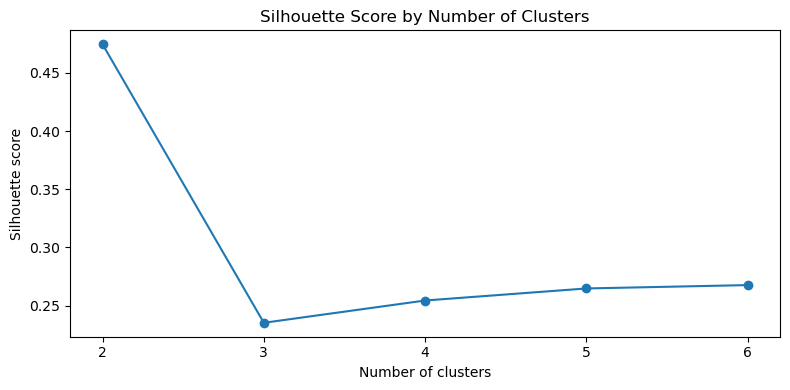

In [26]:

# ========== 4. Choose K by Silhouette Score ==========
results = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({"k": k, "silhouette_score": score})

k_scores = pd.DataFrame(results)
display(k_scores)

best_k = int(k_scores.loc[k_scores["silhouette_score"].idxmax(), "k"])
print("Selected k:", best_k)

plt.figure(figsize=(8, 4))
plt.plot(k_scores["k"], k_scores["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.xticks(k_scores["k"])
plt.tight_layout()
plt.show()


In [27]:

# ========== 5. Fit Final K-Means ==========
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
segment_df["cluster"] = kmeans.fit_predict(X_scaled)

profile = (
    segment_df.groupby("cluster")
    .agg(
        users=("user_id", "nunique"),
        recency_days=("recency_days", "mean"),
        clicks=("clicks", "mean"),
        engagements=("engagements", "mean"),
        purchases=("purchases", "mean"),
        active_days=("active_days", "mean"),
        CTR=("CTR", "mean"),
        CVR=("CVR", "mean")
    )
    .reset_index()
)

profile["user_share"] = profile["users"] / profile["users"].sum()

display(profile.sort_values("users", ascending=False))


,cluster,users,recency_days,clicks,engagements,purchases,active_days,CTR,CVR,user_share
0,0,9352,8.01775,1.198888,0.557100,0.000000,11.225299,0.132989,0.000000,0.940372
1,1,593,7.41484,1.246206,0.569983,1.025295,12.225970,0.137779,0.529904,0.059628


In [28]:

# ========== 6. Descriptive Segment Labels ==========
# Labels are based on observed profile characteristics, not a predictive claim.

labels = {}
for _, row in profile.iterrows():
    if row["purchases"] >= profile["purchases"].median() and row["recency_days"] <= profile["recency_days"].median():
        label = "Recent Converters"
    elif row["clicks"] >= profile["clicks"].median() and row["CVR"] < profile["CVR"].median():
        label = "Frequent Clickers"
    elif row["engagements"] >= profile["engagements"].median():
        label = "Engaged Browsers"
    else:
        label = "Low-Activity Users"
    labels[row["cluster"]] = label

segment_df["segment"] = segment_df["cluster"].map(labels)
profile["segment"] = profile["cluster"].map(labels)

display(profile.sort_values("user_share", ascending=False))


,cluster,users,recency_days,clicks,engagements,purchases,active_days,CTR,CVR,user_share,segment
0,0,9352,8.01775,1.198888,0.557100,0.000000,11.225299,0.132989,0.000000,0.940372,Low-Activity Users
1,1,593,7.41484,1.246206,0.569983,1.025295,12.225970,0.137779,0.529904,0.059628,Recent Converters


In [29]:

# ========== 7. Segment Demographics ==========
for col in ["gender", "country", "device", "age"]:
    if col in segment_df.columns:
        temp = (
            segment_df.groupby(["segment", col], dropna=False)
            .size()
            .reset_index(name="users")
        )
        temp["share_within_segment"] = (
            temp["users"] /
            temp.groupby("segment")["users"].transform("sum")
        )
        temp.to_csv(OUTPUT_DIR / f"segment_{col}.csv", index=False)
        print(f"\n--- {col} ---")
        display(temp.sort_values(["segment", "users"], ascending=[True, False]).head(30))



--- country ---


,segment,country,users,share_within_segment
0,Low-Activity Users,NaN,9352,1.0
1,Recent Converters,NaN,593,1.0


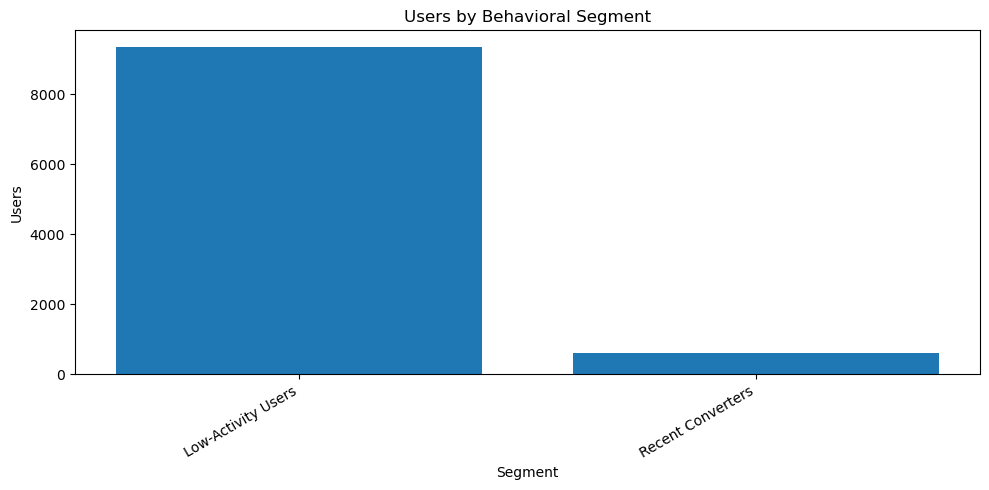

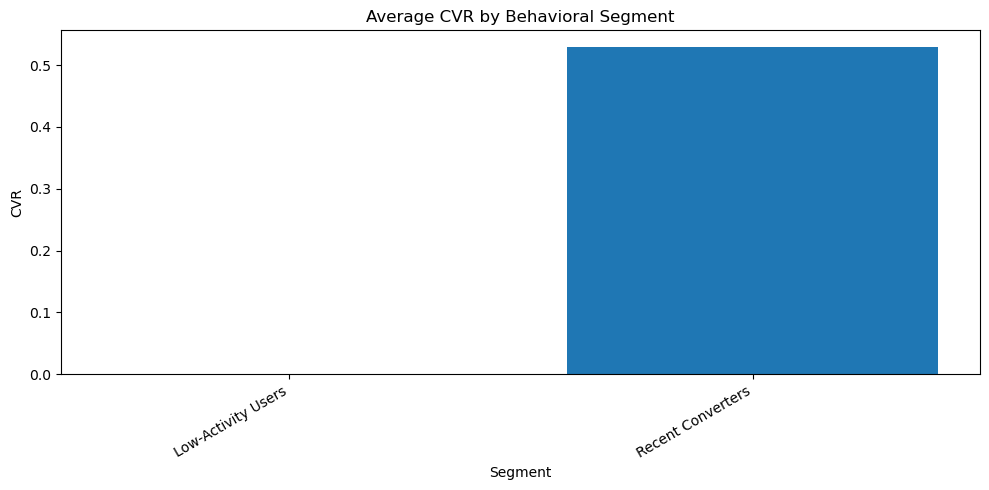

In [30]:

# ========== 8. Segment Visualization ==========
plt.figure(figsize=(10, 5))
plot_df = profile.sort_values("users", ascending=False)
plt.bar(plot_df["segment"], plot_df["users"])
plt.title("Users by Behavioral Segment")
plt.xlabel("Segment")
plt.ylabel("Users")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(profile["segment"], profile["CVR"])
plt.title("Average CVR by Behavioral Segment")
plt.xlabel("Segment")
plt.ylabel("CVR")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [31]:

# ========== 9. Export ==========
segment_df.to_csv(OUTPUT_DIR / "customer_segments.csv", index=False)
profile.to_csv(OUTPUT_DIR / "customer_segment_profile.csv", index=False)

print("Saved customer segmentation outputs.")


Saved customer segmentation outputs.
